# 03 — Loop de Treinamento MLP com Early Stopping

Treina a rede neural `ChurnMLP` em PyTorch com:
- **Otimizador**: Adam (`lr=1e-3`)
- **Loss**: `BCEWithLogitsLoss` com `pos_weight` dinâmico
- **Early stopping**: patience=10 epochs monitorando `val_loss`
- **Arquitetura**: 30 → 128 → 64 → 1 (BatchNorm + ReLU + Dropout 0.3)

O modelo treinado é salvo em `models/churn_mlp.pt`.

In [1]:
import logging
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split

from src.config import RANDOM_SEED
from src.data.loader import load_raw
from src.features.pipeline import fit_preprocessor, split_data
from src.models.trainer import train

logging.basicConfig(
    level=logging.INFO,
    format="%(name)s — %(levelname)s — %(message)s",
)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

print("ROOT:", ROOT)

c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp\.venv\Lib\site-packages\pandera\_pandas_deprecated.py:143: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.html

To disable this warning, set the environment variable:

```
export DISABLE_PANDERA_IMPORT_WARNING=True
```

  warnings.warn(_future_warning, FutureWarning)


ROOT: c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp


## 1. Carregamento e Splits

In [2]:
df = load_raw()
X_train_val, X_test, y_train_val, y_test = split_data(df)

# Split treino / validação (80% / 20% do conjunto de treino+val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=RANDOM_SEED,
)

print(f"Treino : {len(X_train):,} | churn: {y_train.mean():.1%}")
print(f"Val    : {len(X_val):,} | churn: {y_val.mean():.1%}")
print(f"Teste  : {len(X_test):,} | churn: {y_test.mean():.1%}")

n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
print(f"\npos_weight = {n_neg / n_pos:.2f} (n_neg/n_pos)")

src.data.loader — INFO — Carregados 7043 registros × 21 colunas de telco_churn.csv
src.data.loader — WARNING — TotalCharges: 11 valores ausentes — preenchendo com mediana (1397.47)
src.data.loader — INFO — Validação de schema concluída — 7043 registros válidos
src.features.pipeline — INFO — Split — treino/val: 5986 registros | teste holdout: 1057 registros (15%)


Treino : 4,788 | churn: 26.5%
Val    : 1,198 | churn: 26.5%
Teste  : 1,057 | churn: 26.5%

pos_weight = 2.77 (n_neg/n_pos)


## 2. Pré-processamento

In [3]:
preprocessor = fit_preprocessor(X_train, save=True)

X_train_t = preprocessor.transform(X_train)
X_val_t   = preprocessor.transform(X_val)
X_test_t  = preprocessor.transform(X_test)

print(f"Features após transformação: {X_train_t.shape[1]}")

src.features.pipeline — INFO — Preprocessador ajustado — 30 features de saída
src.features.pipeline — INFO — Preprocessador salvo em c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp\models\preprocessor.joblib


Features após transformação: 30


## 3. Treinamento

O treinamento pode levar alguns minutos na CPU. O early stopping interrompe quando `val_loss` não melhora por 10 epochs consecutivas.

In [4]:
result = train(
    X_train_t, y_train,
    X_val_t, y_val,
    run_name="mlp_v1",
)

print(f"\nBest epoch : {result['best_epoch']}")
best = result["best_val_metrics"]
print(f"val_loss   : {best['loss']:.4f}")
print(f"val_auc_roc: {best['auc_roc']:.4f}")
print(f"val_pr_auc : {best['pr_auc']:.4f}")
print(f"val_f1     : {best['f1']:.4f}")

src.models.trainer — INFO — Dispositivo: cpu
2026/05/04 22:13:35 INFO mlflow.tracking.fluent: Experiment with name 'telecom-churn-mlp' does not exist. Creating a new experiment.
src.models.trainer — INFO — Epoch   1 | train: 0.7976 | val_loss: 0.7522 | val_auc: 0.8279 | val_f1: 0.5985
src.models.trainer — INFO — Epoch   2 | train: 0.7374 | val_loss: 0.7497 | val_auc: 0.8291 | val_f1: 0.5967
src.models.trainer — INFO — Epoch   3 | train: 0.7217 | val_loss: 0.7451 | val_auc: 0.8328 | val_f1: 0.6186
src.models.trainer — INFO — Epoch   4 | train: 0.7155 | val_loss: 0.7444 | val_auc: 0.8326 | val_f1: 0.6070
src.models.trainer — INFO — Epoch  10 | train: 0.6992 | val_loss: 0.7574 | val_auc: 0.8286 | val_f1: 0.6175
src.models.trainer — INFO — Early stopping na epoch 14 (patience=10)
src.models.trainer — INFO — Melhor modelo (epoch 4) salvo em c:\Users\henri\OneDrive\Documents\Study\fiap26\telecom-churn-mlp\models\churn_mlp.pt



Best epoch : 4
val_loss   : 0.7444
val_auc_roc: 0.8326
val_pr_auc : 0.6293
val_f1     : 0.6070


## 4. Curvas de Loss

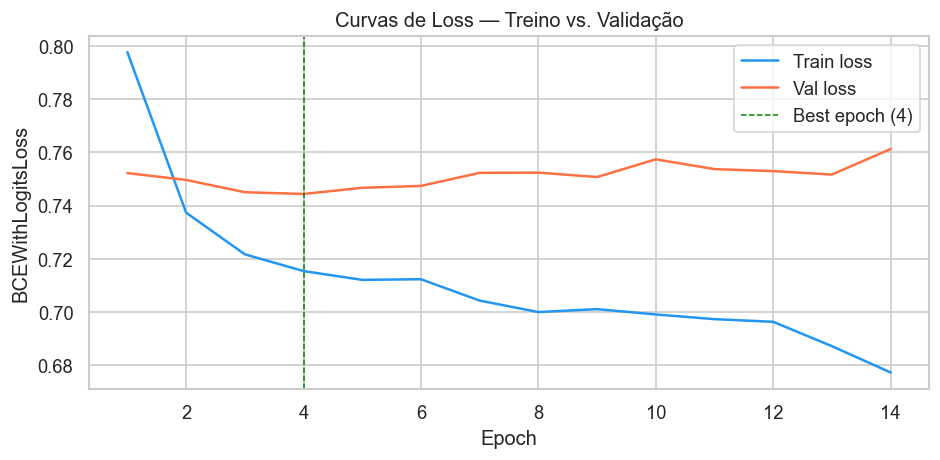

In [5]:
history = result["history"]
epochs      = [h["epoch"]      for h in history]
train_loss  = [h["train_loss"] for h in history]
val_loss    = [h["loss"]       for h in history]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_loss, label="Train loss", color="#2196F3")
ax.plot(epochs, val_loss,   label="Val loss",   color="#FF7043")
ax.axvline(result["best_epoch"], linestyle="--", color="green",
           linewidth=0.9, label=f"Best epoch ({result['best_epoch']})")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCEWithLogitsLoss")
ax.set_title("Curvas de Loss — Treino vs. Validação")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Curvas de Métricas por Epoch

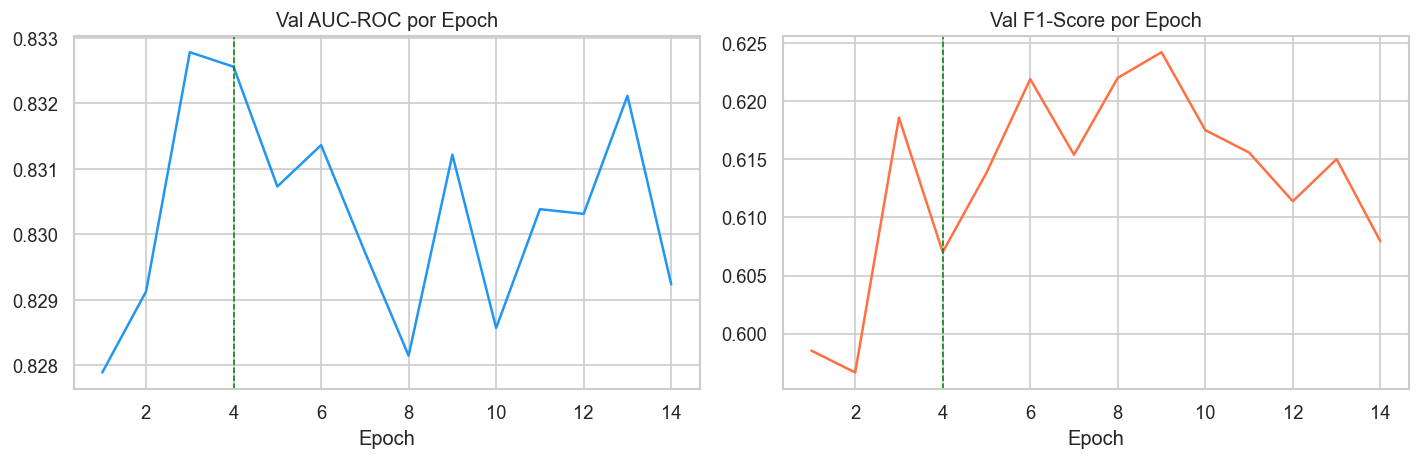

In [6]:
val_auc = [h["auc_roc"] for h in history]
val_f1  = [h["f1"]      for h in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, val_auc, color="#2196F3")
axes[0].axvline(result["best_epoch"], linestyle="--", color="green", linewidth=0.9)
axes[0].set_title("Val AUC-ROC por Epoch")
axes[0].set_xlabel("Epoch")

axes[1].plot(epochs, val_f1, color="#FF7043")
axes[1].axvline(result["best_epoch"], linestyle="--", color="green", linewidth=0.9)
axes[1].set_title("Val F1-Score por Epoch")
axes[1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()

## 6. Distribuição das Probabilidades Preditas

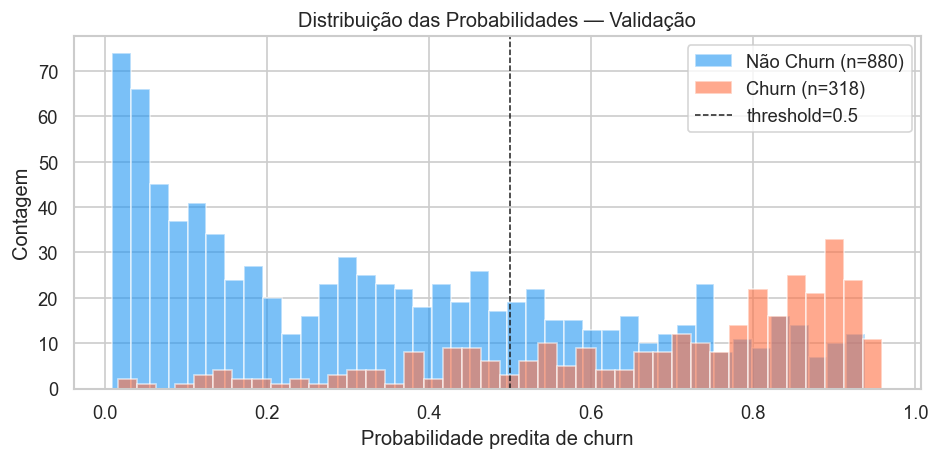

In [7]:
import torch
from src.models.trainer import ChurnDataset
from torch.utils.data import DataLoader

model = result["model"]
model.eval()

val_loader = DataLoader(ChurnDataset(X_val_t, y_val), batch_size=256)
all_probs = []
all_labels = []

with torch.no_grad():
    for X_b, y_b in val_loader:
        probs = torch.sigmoid(model(X_b)).numpy()
        all_probs.extend(probs.tolist())
        all_labels.extend(y_b.numpy().tolist())

prob_df = pd.DataFrame({"prob": all_probs, "churn": all_labels})

fig, ax = plt.subplots(figsize=(8, 4))
for label, color, name in [(0, "#2196F3", "Não Churn"), (1, "#FF7043", "Churn")]:
    subset = prob_df[prob_df["churn"] == label]["prob"]
    ax.hist(subset, bins=40, alpha=0.6, color=color, label=f"{name} (n={len(subset)})")
ax.axvline(0.5, linestyle="--", color="k", linewidth=0.9, label="threshold=0.5")
ax.set_xlabel("Probabilidade predita de churn")
ax.set_ylabel("Contagem")
ax.set_title("Distribuição das Probabilidades — Validação")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Conclusões

- O early stopping interrompeu o treinamento na epoch `best_epoch` — evitando overfitting.
- O `pos_weight` dinâmico (~2.85) força o modelo a penalizar mais os falsos negativos, aumentando o recall da classe churn.
- O modelo foi salvo em `models/churn_mlp.pt`.
- **Próximo passo:** `notebooks/04_model_comparison.ipynb` — comparação quantitativa MLP vs. baselines com análise de threshold e custo de negócio.